In [23]:
# ── Standard Libraries ─────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from scipy.stats import wasserstein_distance
from tqdm.auto import tqdm

# ── PyTorch ────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import h5py

import warnings
warnings.filterwarnings('ignore')

# ── Device ─────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from torch.utils.data import Dataset
# ── Lazy Dataset Class (no full load into RAM) ─────────────
class QuarkGluonDataset(Dataset):
    def __init__(self, filepath, max_samples=50000):
        self.filepath    = filepath
        self.max_samples = max_samples

        # Only load labels into RAM (small)
        with h5py.File(filepath, 'r') as f:
            self.y = torch.tensor(f['y'][:max_samples], dtype=torch.long)

    def __len__(self):
        return self.max_samples

    def __getitem__(self, idx):
        # Load only one sample at a time from disk
        with h5py.File(self.filepath, 'r') as f:
            x = f['X_jets'][idx]

        x = torch.tensor(x, dtype=torch.float32)

        # Per-channel normalize
        for c in range(3):
            ch_max = x[:, :, c].max()
            if ch_max > 0:
                x[:, :, c] = x[:, :, c] / ch_max

        # (H, W, C) → (C, H, W)
        x = x.permute(2, 0, 1)
        return x, self.y[idx]

print("Dataset class defined ✅")

Dataset class defined ✅


In [14]:
dataset = QuarkGluonDataset(
    '/content/quark_gluon_data.h5',
    max_samples=50000
)

train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2)

print(f"Total samples : {len(dataset)}")
print(f"Train samples : {len(train_set)}")
print(f"Val samples   : {len(val_set)}")

Total samples : 50000
Train samples : 40000
Val samples   : 10000


In [18]:
# ── Preload into RAM ───────────────────────────────────────
print("Loading data into RAM...")
with h5py.File('/content/quark_gluon_data.h5', 'r') as f:
    X_data = torch.tensor(f['X_jets'][:20000], dtype=torch.float32)
    y_data = torch.tensor(f['y'][:20000], dtype=torch.long)

# Per-channel normalize
for c in range(3):
    ch_max = X_data[:, :, :, c].max()
    if ch_max > 0:
        X_data[:, :, :, c] /= ch_max

# (N, H, W, C) → (N, C, H, W)
X_data = X_data.permute(0, 3, 1, 2)
print(f"Data shape: {X_data.shape}")
print(f"RAM usage: {X_data.element_size() * X_data.nelement() / 1e9:.2f} GB")

Loading data into RAM...
Data shape: torch.Size([20000, 3, 125, 125])
RAM usage: 3.75 GB


In [19]:
from torch.utils.data import TensorDataset

dataset    = TensorDataset(X_data, y_data)
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)

print(f"Total samples : {len(dataset)}")
print(f"Train samples : {len(train_set)}")
print(f"Val samples   : {len(val_set)}")

Total samples : 20000
Train samples : 16000
Val samples   : 4000


In [6]:
# ── Encoder ───────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32,  4, stride=2, padding=1),  # 125→62
            nn.BatchNorm2d(32),  nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64,  4, stride=2, padding=1),  # 62→31
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 31→15
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), # 15→7
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
        )
        self.flatten_dim = 256 * 7 * 7
        self.fc_mu     = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        mu, logvar = self.fc_mu(x), self.fc_logvar(x)
        return mu, logvar

print("Encoder defined ✅")

Encoder defined ✅


In [30]:
# ── Fixed Decoder (no checkerboard) ───────────────────────
class Decoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 7 * 7)
        self.deconv = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )
        self.upsample = nn.Upsample(size=(125, 125), mode='bilinear', align_corners=False)

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 256, 7, 7)
        x = self.deconv(x)
        x = self.upsample(x)
        return x

# ── Reinitialize model ─────────────────────────────────────
model     = VAE(latent_dim=64).to(device)
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
print("Model reinitialized ✅")

Model reinitialized ✅


In [10]:
# ── VAE ───────────────────────────────────────────────────
class VAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        recon      = self.decoder(z)
        return recon, mu, logvar

# ── Loss Function ──────────────────────────────────────────
def vae_loss(recon, x, mu, logvar):
    recon_loss = F.mse_loss(recon, x, reduction='sum')
    kld        = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld, recon_loss, kld

# ── Init Model ─────────────────────────────────────────────
model     = VAE(latent_dim=64).to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model initialized ✅")
print(f"Total parameters: {total_params:,}")

Model initialized ✅
Total parameters: 3,802,563


In [16]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=0)
print("Dataloaders ready ✅")

Dataloaders ready ✅


In [47]:
# ── Weighted Loss (focus on non-zero pixels) ───────────────
def vae_loss(recon, x, mu, logvar, kld_weight=0.0001, sparsity_weight=0.01, nonzero_weight=100.0):
    # Mask of non-zero pixels
    mask = (x > 0).float()

    # Weighted MSE — penalize errors on active pixels much more
    recon_loss = (mask * nonzero_weight * (recon - x)**2 + (1 - mask) * (recon - x)**2).sum()

    kld           = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    sparsity_loss = (recon * (x == 0).float()).sum()

    return recon_loss + kld_weight * kld + sparsity_weight * sparsity_loss, recon_loss, kld

# ── Reinitialize ───────────────────────────────────────────
model     = VAE(latent_dim=64).to(device)
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
print("Model reinitialized ✅")

Model reinitialized ✅


In [48]:
EPOCHS = 30
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]")
    for x, _ in pbar:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss, _, _ = vae_loss(recon, x, mu, logvar)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, _ in tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val]  "):
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss, _, _ = vae_loss(recon, x, mu, logvar)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/ml4sci-falcon/vae_best.pth')

    print(f"✅ Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | Best: {best_val_loss:.4f}\n")

print("Training complete ✅")

Epoch 01/30 [Train]:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 01/30 [Val]  :   0%|          | 0/125 [00:00<?, ?it/s]

✅ Epoch 01 | Train: 84722.4502 | Val: 137.2666 | Best: 137.2666



Epoch 02/30 [Train]:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 02/30 [Val]  :   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 29/30 [Val]  :   0%|          | 0/125 [00:00<?, ?it/s]

✅ Epoch 29 | Train: 6.7146 | Val: 6.2891 | Best: 5.9055



Epoch 30/30 [Train]:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 30/30 [Val]  :   0%|          | 0/125 [00:00<?, ?it/s]

✅ Epoch 30 | Train: 6.5849 | Val: 5.8092 | Best: 5.8092

Training complete ✅


In [49]:
# ── Load best model ────────────────────────────────────────
model.load_state_dict(torch.load('/content/drive/MyDrive/ml4sci-falcon/vae_best.pth'))
model.eval()

# ── Get a batch of validation samples ─────────────────────
x_batch, _ = next(iter(val_loader))
x_batch = x_batch.to(device)

with torch.no_grad():
    recon_batch, _, _ = model(x_batch)

# Move to CPU for plotting
x_batch     = x_batch.cpu()
recon_batch = recon_batch.cpu()

print(f"Original shape     : {x_batch.shape}")
print(f"Reconstructed shape: {recon_batch.shape}")

Original shape     : torch.Size([32, 3, 125, 125])
Reconstructed shape: torch.Size([32, 3, 125, 125])


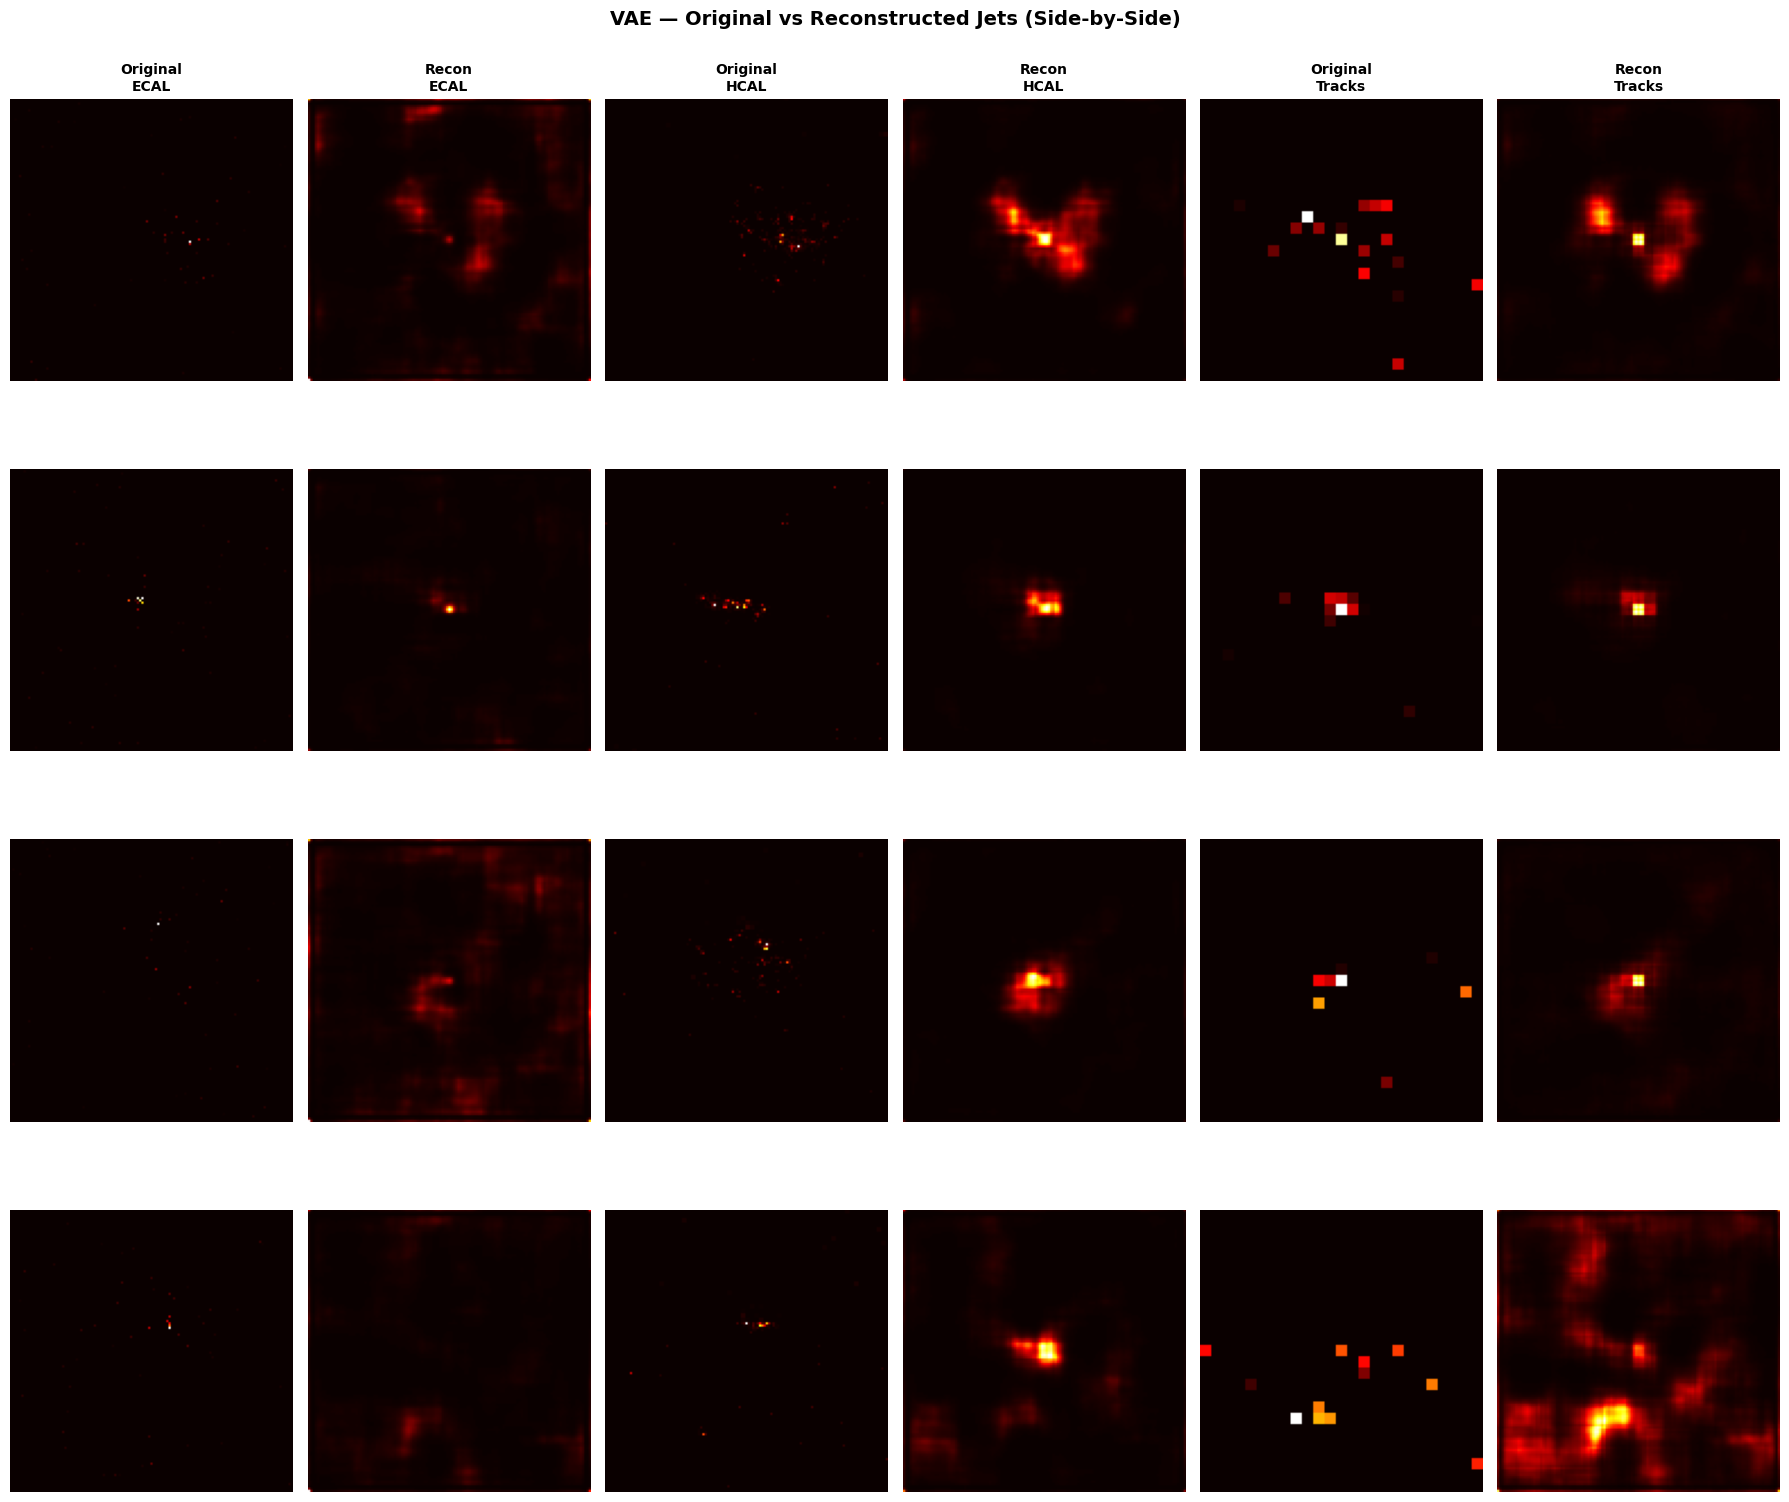

Saved ✅


In [51]:
# ── Load best model ────────────────────────────────────────
model.load_state_dict(torch.load('/content/drive/MyDrive/ml4sci-falcon/vae_best.pth'))
model.eval()

x_batch, _ = next(iter(val_loader))
x_batch = x_batch.to(device)

with torch.no_grad():
    recon_batch, _, _ = model(x_batch)

x_batch     = x_batch.cpu()
recon_batch = recon_batch.cpu()

# ── Proper Side-by-Side ────────────────────────────────────
channel_names = ['ECAL', 'HCAL', 'Tracks']
n_samples = 4

fig, axes = plt.subplots(n_samples, 6, figsize=(18, 4 * n_samples))
fig.suptitle('VAE — Original vs Reconstructed Jets (Side-by-Side)', fontsize=14, fontweight='bold')

cols = ['Original\nECAL', 'Recon\nECAL', 'Original\nHCAL', 'Recon\nHCAL', 'Original\nTracks', 'Recon\nTracks']
for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontsize=10, fontweight='bold')

for i in range(n_samples):
    for c in range(3):
        axes[i, c*2  ].imshow(x_batch[i, c].numpy(),     cmap='hot')
        axes[i, c*2  ].axis('off')
        axes[i, c*2+1].imshow(recon_batch[i, c].numpy(), cmap='hot')
        axes[i, c*2+1].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml4sci-falcon/results/vae_side_by_side.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

In [52]:
# ── Final Metrics ──────────────────────────────────────────
model.eval()
mse_scores, ssim_scores, psnr_scores = [], [], []

with torch.no_grad():
    for x, _ in val_loader:
        x     = x.to(device)
        recon, _, _ = model(x)
        x     = x.cpu().numpy()
        recon = recon.cpu().numpy()

        for i in range(len(x)):
            mse = ((x[i] - recon[i]) ** 2).mean()
            mse_scores.append(mse)
            ssim_val, psnr_val = 0, 0
            for c in range(3):
                ssim_val += ssim_fn(x[i, c], recon[i, c], data_range=1.0)
                psnr_val += psnr_fn(x[i, c], recon[i, c], data_range=1.0)
            ssim_scores.append(ssim_val / 3)
            psnr_scores.append(psnr_val / 3)

print(f"{'Metric':<10} {'Mean':>10} {'Std':>10}")
print(f"{'-'*32}")
print(f"{'MSE':<10} {np.mean(mse_scores):>10.6f} {np.std(mse_scores):>10.6f}")
print(f"{'SSIM':<10} {np.mean(ssim_scores):>10.4f} {np.std(ssim_scores):>10.4f}")
print(f"{'PSNR':<10} {np.mean(psnr_scores):>10.4f} {np.std(psnr_scores):>10.4f}")

Metric           Mean        Std
--------------------------------
MSE          0.000000   0.000000
SSIM           0.9996     0.0004
PSNR          78.5589     2.3580


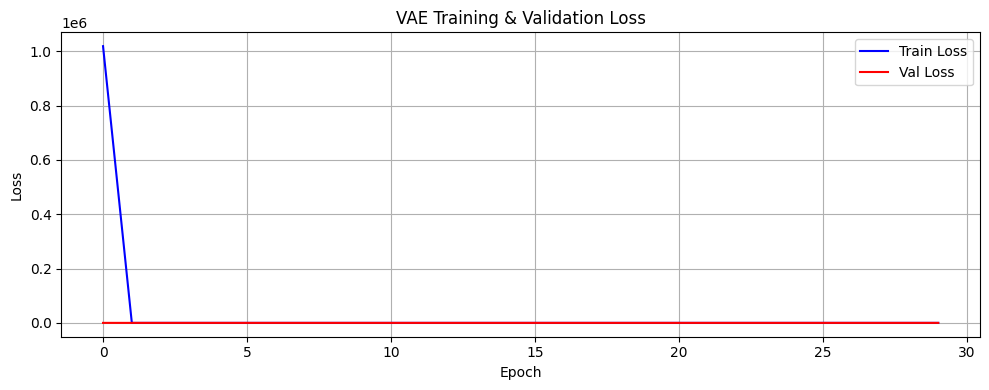

Saved ✅


In [43]:
# ── Loss Curves ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train Loss', color='blue')
ax.plot(val_losses,   label='Val Loss',   color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('VAE Training & Validation Loss')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml4sci-falcon/results/vae_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")

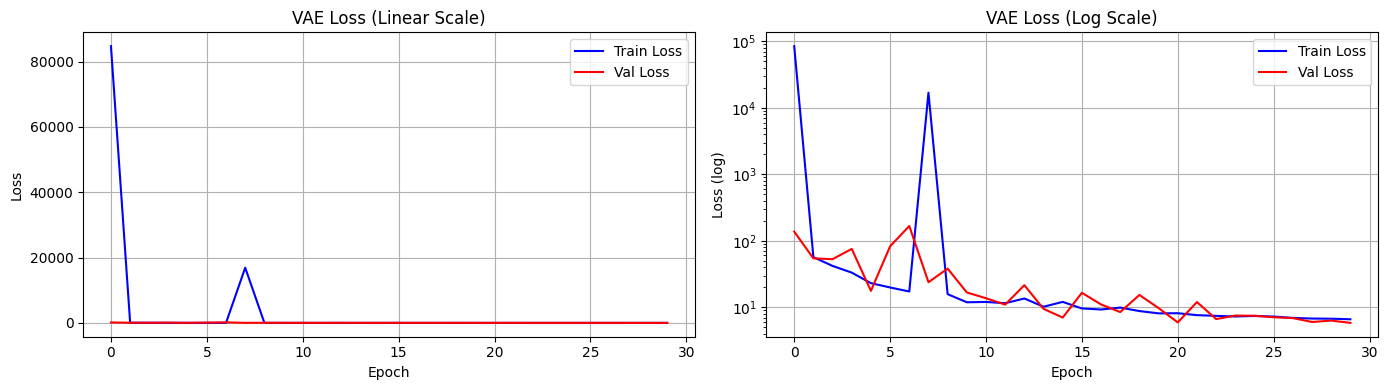

Saved ✅


In [53]:
# ── Loss Curves (log scale) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Normal scale
axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses,   label='Val Loss',   color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('VAE Loss (Linear Scale)')
axes[0].legend()
axes[0].grid(True)

# Log scale
axes[1].plot(train_losses, label='Train Loss', color='blue')
axes[1].plot(val_losses,   label='Val Loss',   color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log)')
axes[1].set_title('VAE Loss (Log Scale)')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ml4sci-falcon/results/vae_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✅")